# NumPy Fundamentals — Notebook 1 of 3
## Table of Contents
1. [Why NumPy?](#Section-1:-Why-NumPy?)
2. [Creating Arrays — Basic](#Section-2:-Creating-Arrays-—-Basic)
3. [Like-Arrays](#Section-3:-Like-Arrays-(zeros_like,-ones_like,-full_like))
4. [Random Array Creation](#Section-4:-Random-Array-Creation)
5. [meshgrid](#Section-5:-meshgrid)
6. [Array Attributes](#Section-6:-Array-Attributes)
7. [Data Types (dtypes)](#Section-7:-Data-Types-(dtypes))
8. [Indexing & Slicing — 1D](#Section-8:-Indexing-&-Slicing-—-1D)
9. [Indexing & Slicing — 2D](#Section-9:-Indexing-&-Slicing-—-2D)
10. [tile() and repeat()](#Section-10:-tile()-and-repeat())
11. [Basic Operations](#Section-11:-Basic-Operations)
12. [Shape Operations](#Section-12:-Shape-Operations)
13. [Aggregation Functions](#Section-13:-Aggregation-Functions)
14. [NaN and Inf](#Section-14:-NaN-and-Inf)
15. [Saving and Loading Arrays](#Section-15:-Saving-and-Loading-Arrays)
16. [Cheat Sheet](#Section-16:-Cheat-Sheet)
17. [Exercises](#Section-17:-Exercises)



## Section 1: Why NumPy?
NumPy arrays are significantly faster and more memory-efficient than Python lists. 
This is because NumPy arrays are stored in contiguous memory blocks, hold elements of the same data type, and allow for vectorized operations (operations on whole arrays without explicit loops) implemented in C.


Memory comparison — `sys.getsizeof` on Python list vs numpy array (N=1,000,000)


In [8]:
import numpy as np
import sys

# Create a list and array of 1,000,000 integers
py_list = list(range(1000000))
np_array = np.arange(1000000, dtype=np.int64)

print(f"Python list memory: {sys.getsizeof(py_list) / 1024 / 1024:.2f} MB")
print(f"NumPy array memory: {np_array.nbytes / 1024 / 1024:.2f} MB")



Python list memory: 7.63 MB
NumPy array memory: 7.63 MB


Speed benchmark — `timeit`: sum of list vs `np.sum` (show how many times faster)


In [11]:
import timeit

list_time = timeit.timeit("sum(py_list)", globals=globals(), number=100)
numpy_time = timeit.timeit("np.sum(np_array)", globals=globals(), number=100)

print(f"Python sum time: {list_time:.4f} seconds")
print(f"NumPy sum time: {numpy_time:.4f} seconds")
print(f"NumPy is {list_time / numpy_time:.1f}x faster!")



Python sum time: 1.0161 seconds
NumPy sum time: 0.0371 seconds
NumPy is 27.4x faster!


Matplotlib bar chart showing speed and memory comparison side by side


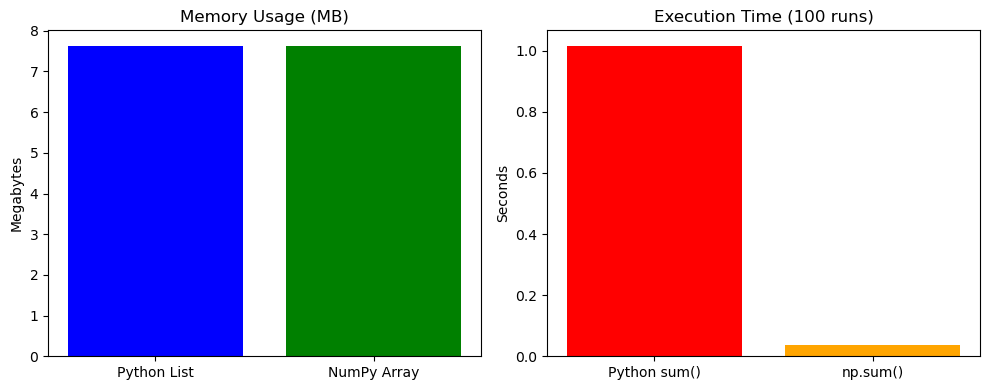

In [16]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Memory Plot
ax1.bar(['Python List', 'NumPy Array'], [sys.getsizeof(py_list)/1024/1024, np_array.nbytes/1024/1024], color=['blue', 'green'])
ax1.set_title('Memory Usage (MB)')
ax1.set_ylabel('Megabytes')

# Speed Plot
ax2.bar(['Python sum()', 'np.sum()'], [list_time, numpy_time], color=['red', 'orange'])
ax2.set_title('Execution Time (100 runs)')
ax2.set_ylabel('Seconds')

plt.tight_layout()
plt.show()



## Section 2: Creating Arrays — Basic
Let's explore the fundamental ways to create NumPy arrays from scratch or existing data.


`np.array()` from a Python list — 1D: Creates a 1D array from a standard list.


In [19]:
temperatures = [22.5, 23.1, 24.0, 21.8, 22.9]
arr_1d = np.array(temperatures)
print(arr_1d)



[22.5 23.1 24.  21.8 22.9]


`np.array()` from a nested list — 2D matrix: Creates a 2D array (matrix) from a list of lists.


In [21]:
pixels = [
    [255, 128, 0], 
    [0, 255, 128], 
    [128, 0, 255]
]
arr_2d = np.array(pixels)
print(arr_2d)



[[255 128   0]
 [  0 255 128]
 [128   0 255]]


`np.array()` with `dtype` specified: Forces the array to have a specific data type (e.g., 32-bit float).


In [22]:
prices = [10, 20, 30]
arr_dtype = np.array(prices, dtype=np.float32)
print(arr_dtype)
print(arr_dtype.dtype)



[10. 20. 30.]
float32


`np.zeros(shape)` — 1D: Creates an array filled with zeros.


In [23]:
zeros_1d = np.zeros(5)
print(zeros_1d)



[0. 0. 0. 0. 0.]


`np.zeros((rows, cols))` — 2D: Creates a 2D matrix of zeros, often used to initialize weights.


In [24]:
zeros_2d = np.zeros((3, 4))
print(zeros_2d)



[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


`np.ones(shape)`: Creates an array filled with ones.


In [25]:
ones_arr = np.ones((2, 3))
print(ones_arr)



[[1. 1. 1.]
 [1. 1. 1.]]


`np.full(shape, fill_value)`: Creates an array filled with a specific value.


In [30]:
background_mask = np.full((3, 3), 255)
print(background_mask)



[[255 255 255]
 [255 255 255]
 [255 255 255]]


`np.arange(start, stop, step)`: Creates an array with evenly spaced values within a given interval.


In [ ]:
even_numbers = np.arange(0, 10,2 )
print(even_numbers)



[0 1 2 3 4 5 6 7 8 9]


`np.linspace(start, stop, num)` — evenly spaced: Creates an array of `num` evenly spaced values between start and stop. Great for plotting functions.


In [31]:
x_vals = np.linspace(0, 1, 5)
print(x_vals)



[0.   0.25 0.5  0.75 1.  ]


`np.eye(n)` — identity matrix: Creates an NxN matrix with 1s on the diagonal and 0s elsewhere.


In [ ]:
identity = np.eye(4)
print(identity)



`np.empty(shape)` — uninitialized (fast creation): Creates an array without initializing entries. The content is whatever was already in memory.


In [46]:
uninitialized = np.empty((2, 2))
print(uninitialized)



[[0.25 0.5 ]
 [0.75 1.  ]]


## Section 3: Like-Arrays (zeros_like, ones_like, full_like)
These functions create new arrays with the exact same shape and data type as an existing array, which is very common in machine learning when you need a mask or an output buffer of the same dimensions as your input.


`np.zeros_like(existing_array)`: Creates an array of zeros with the same shape/dtype.


In [51]:
image_batch = np.array([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])
zeros_match = np.zeros_like(image_batch)
print("Original shape:", image_batch.shape)
print("Zeros_like shape:", zeros_match.shape)



Original shape: (2, 2, 2)
Zeros_like shape: (2, 2, 2)


`np.ones_like(existing_array)`: Creates an array of ones with the same shape/dtype.


In [52]:
ones_match = np.ones_like(image_batch)
print(ones_match)



[[[1 1]
  [1 1]]

 [[1 1]
  [1 1]]]


`np.full_like(existing_array, fill_value)`: Creates an array filled with a specific value matching the shape.


In [53]:
full_match = np.full_like(image_batch, -1)
print(full_match)



[[[-1 -1]
  [-1 -1]]

 [[-1 -1]
  [-1 -1]]]


Real use case — creating a zero-initialized output array same shape as input batch


In [54]:
# Suppose we have an input batch of sensor readings
sensor_readings = np.random.rand(32, 10) # 32 samples, 10 features
# We want to store smoothed output
smoothed_output = np.zeros_like(sensor_readings)
print("Output buffer ready. Shape:", smoothed_output.shape)



Output buffer ready. Shape: (32, 10)


## Section 4: Random Array Creation
NumPy provides powerful random number generation tools.


`np.random.seed(42)` — Setting a seed ensures that random numbers generated are exactly the same every time the code is run. This is crucial for reproducibility in machine learning.


In [55]:
np.random.seed(42)
print("Seed set to 42")



Seed set to 42


`np.random.rand(rows, cols)` — Generates numbers from a uniform distribution over [0, 1).


In [57]:
uniform_0_1 = np.random.rand(2, 3)
print(uniform_0_1)



[[0.05808361 0.86617615 0.60111501]
 [0.70807258 0.02058449 0.96990985]]


`np.random.randn(rows, cols)` — Generates numbers from a standard normal distribution (mean 0, variance 1).


In [59]:
std_normal = np.random.randn(2, 3)
print(std_normal)



[[-1.72491783 -0.56228753 -1.01283112]
 [ 0.31424733 -0.90802408 -1.4123037 ]]


`np.random.randint(low, high, size)` — Generates random integers from low (inclusive) to high (exclusive).


In [63]:
dice_rolls = np.random.randint(1, 7, size=(3, 3))
print(dice_rolls)



[[1 2 4]
 [1 4 6]
 [2 2 1]]


`np.random.uniform(low, high, size)` — Uniform distribution over a specific range [low, high).


In [67]:
custom_uniform = np.random.uniform(-5, 5, size=5)
print(custom_uniform)



[-0.50245867 -1.04849764  4.26658866  2.27271996 -1.73459231]


`np.random.normal(mean, std, size)` — Normal distribution with a specific mean and standard deviation.


In [69]:
heights = np.random.normal(loc=170, scale=10, size=5)
print(heights)



[170.85923472 154.90042718 177.21502462 161.56580077 164.86674595]


Visualize random distributions with matplotlib histogram (4 subplots: uniform, normal, randn, randint)


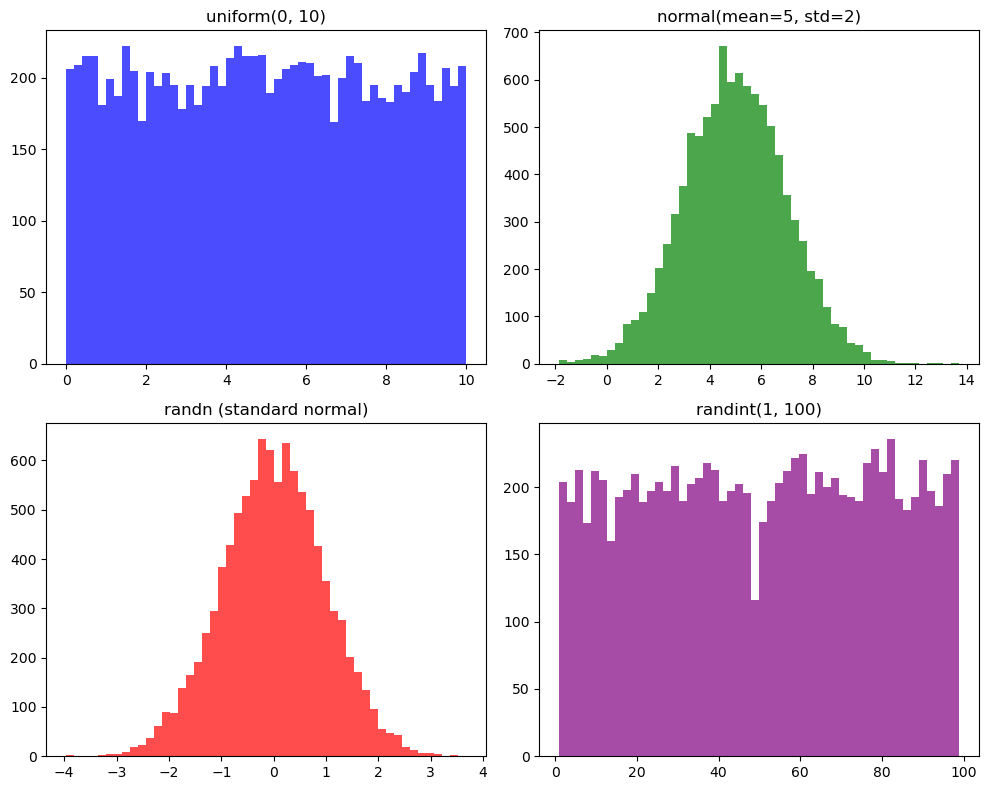

In [73]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

axs[0, 0].hist(np.random.uniform(0, 10, 10000), bins=50, color='blue', alpha=0.7)
axs[0, 0].set_title('uniform(0, 10)')

axs[0, 1].hist(np.random.normal(5, 2, 10000), bins=50, color='green', alpha=0.7)
axs[0, 1].set_title('normal(mean=5, std=2)')

axs[1, 0].hist(np.random.randn(10000), bins=50, color='red', alpha=0.7)
axs[1, 0].set_title('randn (standard normal)')

axs[1, 1].hist(np.random.randint(1, 100, 10000), bins=50, color='purple', alpha=0.7)
axs[1, 1].set_title('randint(1, 100)')

plt.tight_layout()
plt.show()



## Section 5: meshgrid
`np.meshgrid` creates a rectangular grid out of two given 1D arrays representing the Cartesian indexing or Matrix indexing. It's heavily used in ML for plotting decision boundaries or evaluating functions over a 2D space.


`np.meshgrid([1,2,3], [4,5,6])` — show x and y grids


In [74]:
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])
X, Y = np.meshgrid(x, y)
print("X grid:\n", X)
print("\nY grid:\n", Y)



X grid:
 [[1 2 3]
 [1 2 3]
 [1 2 3]]

Y grid:
 [[4 4 4]
 [5 5 5]
 [6 6 6]]


Real ML use — create a 2D grid over feature space and visualize with `plt.contourf`


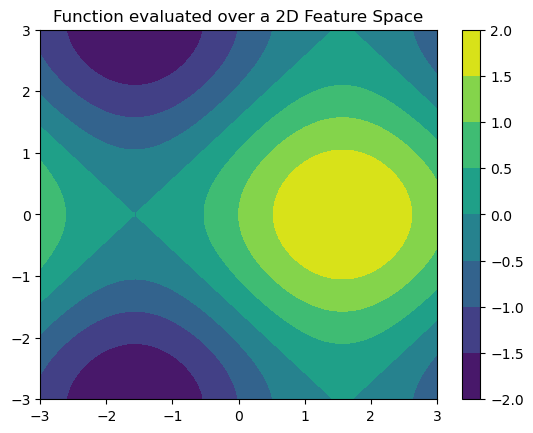

In [75]:
# Evaluate a function (e.g., model predictions) over a grid
x_feat = np.linspace(-3, 3, 100)
y_feat = np.linspace(-3, 3, 100)
X_grid, Y_grid = np.meshgrid(x_feat, y_feat)

# A dummy function: Z = sin(X) + cos(Y)
Z = np.sin(X_grid) + np.cos(Y_grid)

plt.contourf(X_grid, Y_grid, Z, cmap='viridis')
plt.colorbar()
plt.title("Function evaluated over a 2D Feature Space")
plt.show()



## Section 6: Array Attributes
Understanding the shape and type of your arrays is a fundamental skill, especially when debugging ML models where shape mismatches are the most common error.


`.shape` — show for 1D, 2D, 3D arrays


In [76]:
a1 = np.ones(5)
a2 = np.ones((3, 4))
a3 = np.ones((2, 3, 4))
print("1D shape:", a1.shape)
print("2D shape:", a2.shape)
print("3D shape:", a3.shape)



1D shape: (5,)
2D shape: (3, 4)
3D shape: (2, 3, 4)


`.ndim` — number of dimensions


In [77]:
print("Dimensions of a3:", a3.ndim)



Dimensions of a3: 3


`.size` — total number of elements


In [78]:
print("Total elements in a3:", a3.size)



Total elements in a3: 24


`.dtype` — data type


In [79]:
print("Data type of a3:", a3.dtype)



Data type of a3: float64


`.itemsize` — bytes per element


In [80]:
print("Bytes per element in a3:", a3.itemsize)



Bytes per element in a3: 8


`.nbytes` — total memory used


In [81]:
print("Total bytes used by a3:", a3.nbytes)



Total bytes used by a3: 192


Real example — show attributes of a neural network weight matrix (100x50)


In [82]:
# Neural network layer mapping 100 inputs to 50 outputs
weights = np.random.randn(100, 50).astype(np.float32)
print("Weight matrix shape:", weights.shape)
print("Total parameters:", weights.size)
print("Memory footprint (bytes):", weights.nbytes)
print("Data type:", weights.dtype)



Weight matrix shape: (100, 50)
Total parameters: 5000
Memory footprint (bytes): 20000
Data type: float32


## Section 7: Data Types (dtypes)
| Data type | Description |
|---|---|
| `int8`, `int16`, `int32`, `int64` | Signed integers of different bit sizes |
| `float32`, `float64` | Floating-point numbers |
| `bool` | Boolean (True/False) |
| `complex` | Complex numbers |


Create arrays with different dtypes — compare `.nbytes`


In [ ]:
arr_float64 = np.ones((1000, 1000), dtype=np.float64)
arr_int8 = np.ones((1000, 1000), dtype=np.int8)

print(f"float64 memory: {arr_float64.nbytes / 1024 / 1024:.2f} MB")
print(f"int8 memory: {arr_int8.nbytes / 1024 / 1024:.2f} MB")



`astype()` — convert float64 to float32 (save memory for ML)


In [ ]:
arr_float32 = arr_float64.astype(np.float32)
print(f"float32 memory: {arr_float32.nbytes / 1024 / 1024:.2f} MB")



`astype()` — convert to bool (useful for masks)


In [ ]:
mask_numeric = np.array([0, 1, 0, 3])
mask_bool = mask_numeric.astype(bool)
print(mask_bool)



What happens when you mix dtypes — type promotion


In [ ]:
mixed_arr = np.array([1, 2.5, 3]) # int mixed with float
print("Array:", mixed_arr)
print("Inferred dtype:", mixed_arr.dtype) # Promotes to float64



ML tip — why `float32` (not `float64`) is preferred in deep learning (memory chart)


In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
dtypes = ['float64', 'float32', 'float16']
memory_mb = [8, 4, 2] # Relative memory for 1 million elements

ax.bar(dtypes, memory_mb, color=['red', 'orange', 'green'])
ax.set_title('Memory Usage per 1 Million Elements')
ax.set_ylabel('Megabytes')
plt.show()
print("float32 halves memory requirements compared to float64 and is precise enough for most deep learning.")



## Section 8: Indexing & Slicing — 1D
NumPy indexing is 0-based. You can use negative indices to count from the back.


Basic index access `arr[0]`, `arr[-1]`


In [83]:
a = np.arange(10, 20)
print("Array:", a)
print("First element:", a[0])
print("Last element:", a[-1])



Array: [10 11 12 13 14 15 16 17 18 19]
First element: 10
Last element: 19


Slice `arr[start:stop]`


In [84]:
print("Slice from index 2 to 5 (exclusive):", a[2:5])



Slice from index 2 to 5 (exclusive): [12 13 14]


Step slice `arr[::2]` — every other element


In [85]:
print("Every other element:", a[::2])



Every other element: [10 12 14 16 18]


Reverse `arr[::-1]`


In [86]:
print("Reversed array:", a[::-1])



Reversed array: [19 18 17 16 15 14 13 12 11 10]


Negative slicing `arr[-3:]`


In [87]:
print("Last 3 elements:", a[-3:])



Last 3 elements: [17 18 19]


## Section 9: Indexing & Slicing — 2D
For 2D arrays, indexing follows a `[row, col]` pattern.


Access single element `arr[row, col]`


In [88]:
matrix = np.arange(1, 13).reshape(3, 4)
print("Matrix:\n", matrix)
print("\nElement at row 1, col 2:", matrix[1, 2])



Matrix:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Element at row 1, col 2: 7


Select entire row `arr[1, :]`


In [91]:
print("Second row:", matrix[1, :])



Second row: [5 6 7 8]


Select entire column `arr[:, 2]`


In [92]:
print("Third column:", matrix[:, 2])



Third column: [ 3  7 11]


Select submatrix `arr[1:3, 1:4]`


In [93]:
print("Submatrix (bottom right):\n", matrix[1:3, 1:4])



Submatrix (bottom right):
 [[ 6  7  8]
 [10 11 12]]


Select every other row `arr[::2, :]`


In [94]:
print("Every other row:\n", matrix[::2, :])



Every other row:
 [[ 1  2  3  4]
 [ 9 10 11 12]]


Ellipsis `...` for N-dim arrays — `arr[..., 0]` meaning


In [95]:
# ... means 'select all slices in the preceding dimensions'
# Helpful for high dimensional tensors
tensor3d = np.random.randint(0, 10, (2, 3, 4))
print("Select the first element along the last dimension:\n", tensor3d[..., 0])



Select the first element along the last dimension:
 [[7 3 3]
 [9 1 2]]


## Section 10: tile() and repeat()
`np.tile` repeats the whole array structure, whereas `np.repeat` repeats the individual elements.


`np.tile(arr, reps)` — tile the whole array


In [99]:
arr = np.array([1, 2, 3])
tiled = np.tile(arr, 3)
print("Tiled:", tiled)



Tiled: [1 2 3 1 2 3 1 2 3]


`np.repeat(arr, repeats, axis)` — repeat each element


In [100]:
repeated = np.repeat(arr, 2)
print("Repeated:", repeated)



Repeated: [1 1 2 2 3 3]


Real ML use — tile a bias vector across a batch


In [ ]:
bias_vector = np.array([0.5, -0.5])
batch_size = 4
# Tile the bias vector to add to a batch of 4 samples
tiled_bias = np.tile(bias_vector, (batch_size, 1))
print("Tiled bias for batch addition:\n", tiled_bias)



## Section 11: Basic Operations
NumPy operations are element-wise by default. We'll also preview broadcasting, where NumPy automatically handles operations between arrays of different shapes.


Array + Array (element-wise addition)


In [101]:
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])
print("a + b =", a + b)



a + b = [11 22 33]


Array - Array (element-wise subtraction)


In [102]:
print("b - a =", b - a)



b - a = [ 9 18 27]


Array * Array (element-wise multiplication — NOT matrix multiply!)


In [103]:
print("a * b =", a * b)



a * b = [10 40 90]


Array / Array (element-wise division)


In [104]:
print("b / a =", b / a)



b / a = [10. 10. 10.]


Array + scalar (broadcasting scalar)


In [ ]:
print("a + 100 =", a + 100)



Array ** 2 (power)


In [105]:
print("a ** 2 =", a ** 2)



a ** 2 = [1 4 9]


Comparison operators — `arr > 5`, `arr == 3`


In [ ]:
c = np.array([2, 5, 8, 3])
print("c > 5:", c > 5)
print("c == 3:", c == 3)



Universal functions — `np.sqrt`, `np.abs`, `np.exp`, `np.log`


In [106]:
d = np.array([1, 4, 9])
print("sqrt:", np.sqrt(d))
print("exp:", np.exp(d))



sqrt: [1. 2. 3.]
exp: [2.71828183e+00 5.45981500e+01 8.10308393e+03]


## Section 12: Shape Operations
Reshaping is constant in ML (e.g., flattening an image array to feed into a dense layer, or adding a batch dimension).


`reshape()` — 12 elements → (3,4) matrix


In [107]:
arr = np.arange(12)
reshaped = arr.reshape(3, 4)
print(reshaped)



[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


`reshape()` with -1 — let numpy infer one dimension


In [108]:
inferred = arr.reshape(2, -1)
print("Shape inferred as:", inferred.shape)



Shape inferred as: (2, 6)


`flatten()` — always returns a copy


In [109]:
flat_copy = reshaped.flatten()
print("Flattened:", flat_copy)



Flattened: [ 0  1  2  3  4  5  6  7  8  9 10 11]


`ravel()` — returns view when possible (faster)


In [110]:
flat_view = reshaped.ravel()
print("Raveled:", flat_view)



Raveled: [ 0  1  2  3  4  5  6  7  8  9 10 11]


`.T` — transpose of a 2D matrix


In [111]:
print("Original:\n", reshaped)
print("Transposed:\n", reshaped.T)



Original:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Transposed:
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]


`expand_dims()` — add a new axis (add batch dimension)


In [112]:
img = np.random.rand(28, 28)
batch_img = np.expand_dims(img, axis=0)
print("Original shape:", img.shape)
print("With batch dim:", batch_img.shape)



Original shape: (28, 28)
With batch dim: (1, 28, 28)


`squeeze()` — remove dimensions of size 1


In [113]:
squeezed_img = np.squeeze(batch_img)
print("After squeeze:", squeezed_img.shape)



After squeeze: (28, 28)


Real ML use — flatten an image (28,28) → (784,) for dense layer input


In [114]:
image_28x28 = np.random.rand(28, 28)
flattened_for_dense = image_28x28.reshape(-1)
print("Dense layer input shape:", flattened_for_dense.shape)



Dense layer input shape: (784,)


## Section 13: Aggregation Functions
Aggregations summarize data. The `axis` parameter dictates the direction.
- `axis=0` aggregates along the rows (downwards, computing stats for each column).
- `axis=1` aggregates along the columns (across, computing stats for each row).


`np.sum()` — total sum


In [115]:
mat = np.array([[1, 2], [3, 4]])
print("Total sum:", np.sum(mat))



Total sum: 10


`np.sum(arr, axis=0)` — sum along rows (column-wise)


In [116]:
print("Sum axis 0 (column sums):", np.sum(mat, axis=0))



Sum axis 0 (column sums): [4 6]


`np.sum(arr, axis=1)` — sum along columns (row-wise)


In [117]:
print("Sum axis 1 (row sums):", np.sum(mat, axis=1))



Sum axis 1 (row sums): [3 7]


`np.mean()` with axis


In [118]:
print("Mean of each column:", np.mean(mat, axis=0))



Mean of each column: [2. 3.]


`np.std()` with axis — standard deviation


In [119]:
print("Std dev of each column:", np.std(mat, axis=0))



Std dev of each column: [1. 1.]


`np.min()` and `np.max()` with axis


In [122]:
print("Max of each row:", np.max(mat, axis=1))



Max of each row: [2 4]


`np.argmin()` and `np.argmax()` — index of min/max


In [123]:
arr = np.array([10, 50, 20, 90, 30])
print("Index of max value:", np.argmax(arr))



Index of max value: 3


Matplotlib heatmap showing a matrix with its row/column sums annotated


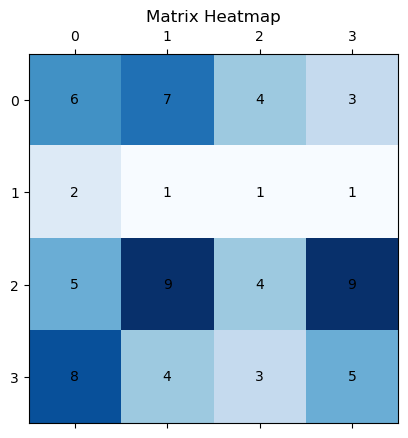

Row sums: [20  5 27 20]
Column sums: [21 21 12 18]


In [128]:
mat_large = np.random.randint(1, 10, (4, 4))
row_sums = mat_large.sum(axis=1)
col_sums = mat_large.sum(axis=0)

fig, ax = plt.subplots()
cax = ax.matshow(mat_large, cmap='Blues')

for i in range(4):
    for j in range(4):
        ax.text(j, i, str(mat_large[i, j]), va='center', ha='center')

plt.title("Matrix Heatmap")
plt.show()
print("Row sums:", row_sums)
print("Column sums:", col_sums)



## Section 14: NaN and Inf
In ML, invalid operations like log(0) or extreme overflows yield Not-a-Number (NaN) or Infinity (Inf).


Creating NaN and Inf — `np.nan`, `np.inf`, `-np.inf`


In [129]:
nan_val = np.nan
inf_val = np.inf
print("NaN:", nan_val, "| Inf:", inf_val)



NaN: nan | Inf: inf


`np.isnan()` — check for NaN


In [130]:
arr = np.array([1, 2, np.nan, 4])
print("Is NaN:", np.isnan(arr))



Is NaN: [False False  True False]


`np.isinf()` — check for Inf


In [131]:
arr2 = np.array([1, np.inf, 3])
print("Is Inf:", np.isinf(arr2))



Is Inf: [False  True False]


`np.isfinite()` — check for finite values


In [132]:
print("Is Finite:", np.isfinite(arr2))



Is Finite: [ True False  True]


`np.nan_to_num()` — replace NaN with 0, Inf with large number


In [135]:
cleaned = np.nan_to_num(np.array([1, np.nan, np.inf]))
print("Cleaned array:", cleaned)



Cleaned array: [1.00000000e+000 0.00000000e+000 1.79769313e+308]


NaN-safe aggregations — `np.nansum`, `np.nanmean`, `np.nanstd`, `np.nanmax`


In [136]:
arr_with_nan = np.array([10, 20, np.nan, 30])
print("Standard sum (fails):", np.sum(arr_with_nan))
print("NaN-safe sum:", np.nansum(arr_with_nan))



Standard sum (fails): nan
NaN-safe sum: 60.0


## Section 15: Saving and Loading Arrays
Saving your arrays is important for checkpointing data preprocessing or saving model weights.


`np.save('file.npy', arr)` and `np.load('file.npy')` — single array


In [ ]:
save_path = '/Users/hemlata/Desktop/File Handling/single_array.npy'
arr_to_save = np.array([1, 2, 3, 4, 5])
np.save(save_path, arr_to_save)
loaded_arr = np.load(save_path)
print("Loaded single array:", loaded_arr)



`np.savez('file.npz', x=arr1, y=arr2)` — multiple arrays


In [ ]:
savez_path = '/Users/hemlata/Desktop/File Handling/multi_array.npz'
arr_x = np.array([1, 2])
arr_y = np.array([3, 4])
np.savez(savez_path, x=arr_x, y=arr_y)



`np.load('file.npz')` — load named arrays from npz


In [ ]:
loaded_npz = np.load(savez_path)
print("Loaded x from npz:", loaded_npz['x'])
print("Loaded y from npz:", loaded_npz['y'])



`np.savetxt('file.csv', arr, delimiter=',')` — save as CSV


In [ ]:
csv_path = '/Users/hemlata/Desktop/File Handling/data.csv'
data = np.array([[1, 2], [3, 4]])
np.savetxt(csv_path, data, delimiter=',')



`np.loadtxt('file.csv', delimiter=',')` — load from CSV


In [ ]:
loaded_csv = np.loadtxt(csv_path, delimiter=',')
print("Loaded CSV data:\n", loaded_csv)



`np.genfromtxt('file.csv', delimiter=',', names=True)` — load with headers


In [ ]:
# Create a CSV with a header first for this example
csv_header_path = '/Users/hemlata/Desktop/File Handling/data_header.csv'
with open(csv_header_path, 'w') as f:
    f.write("A,B\n1.5,2.5\n3.5,4.5")

loaded_header_csv = np.genfromtxt(csv_header_path, delimiter=',', names=True)
print("Loaded with headers:", loaded_header_csv)



## Section 16: Cheat Sheet
| Function/Method | Description |
|---|---|
| `np.array(list)` | Create array from list |
| `np.zeros(shape)`, `np.ones(shape)` | Array of 0s or 1s |
| `np.arange(start, stop, step)` | Evenly spaced values |
| `np.linspace(start, stop, num)` | `num` evenly spaced values |
| `np.random.rand()`, `randn()`, `randint()` | Random numbers |
| `arr.shape`, `arr.dtype`, `arr.ndim` | Array attributes |
| `arr.reshape(shape)` | Change shape |
| `arr.sum(axis)`, `arr.mean(axis)` | Aggregations |
| `np.isnan(arr)` | Check for NaN |
| `np.save()`, `np.load()` | Save/load arrays |


## Section 17: Exercises


**Exercise 1**: Create a 2D array of shape (4, 4) filled with random integers between 1 and 100. Print its shape and memory size (in bytes).


In [ ]:
# Try it here



In [138]:
# Solution
ex1_arr = np.random.randint(1, 100, (4, 4))
print("Shape:", ex1_arr.shape)
print("Bytes:", ex1_arr.nbytes)



Shape: (4, 4)
Bytes: 128


**Exercise 2**: Create a 1D array from 10 to 50. Slice it to get every 3rd element in reverse order.


In [ ]:
# Try it here



In [139]:
# Solution
ex2_arr = np.arange(10, 50)
print(ex2_arr[::-3])



[49 46 43 40 37 34 31 28 25 22 19 16 13 10]


**Exercise 3**: Create a (6, 2) array of ones. Reshape it to a (3, 4) array. Flatten it. Add a batch dimension to the flattened array.


In [149]:
# Try it here



In [148]:
# Solution
ex3_arr = np.ones((6, 2))
reshaped = ex3_arr.reshape(3, 4)
flattened = reshaped.flatten()
batched = np.expand_dims(flattened, axis=0)
print("Final shape:", batched.shape)



Final shape: (1, 12)


**Exercise 4**: Create a 3x3 matrix. Calculate the sum of the elements in the last column.


In [ ]:
# Try it here



In [ ]:
# Solution
ex4_mat = np.random.rand(3, 3)
last_col_sum = np.sum(ex4_mat[:, -1])
print("Sum of last column:", last_col_sum)



**Exercise 5**: Create an array `[5, np.nan, 2, np.nan, 8]`. Calculate the mean, ignoring the NaN values. Then replace NaNs with 0.


In [ ]:
# Try it here



In [ ]:
# Solution
ex5_arr = np.array([5, np.nan, 2, np.nan, 8])
print("Mean (ignoring NaNs):", np.nanmean(ex5_arr))
cleaned = np.nan_to_num(ex5_arr, nan=0.0)
print("Cleaned:", cleaned)

